In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
# df = pd.read_csv("sample_superstore_sql_updated.csv")

# This error occurs because the CSV file contains characters that are not encoded in UTF-8 format. The pandas `read_csv()` function expects 
# UTF-8 encoding by default, but your file appears to be encoded in a different format (possibly Latin-1, Windows-1252, or another encoding).
# The error happens when pandas encounters a byte (0xf6) that is not valid in UTF-8 encoding at position 9712 in the file.
# correct alternative code-

df = pd.read_csv(
    "sample_superstore_sql_updated.csv",
    encoding="latin-1",
    parse_dates=["Order Date", "Ship Date"]
)
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,541,CA-2014-140795,02-01-2014,03-02-2014,First Class,BD-11500,Bradley Drucker,Consumer,United States,Green Bay,...,54302,Central,TEC-AC-10001432,Technology,Accessories,Enermax Aurora Lite Keyboard,468.90,6,0.0,206.3160
1,5714,US-2014-143707,03-01-2014,05-03-2014,Standard Class,HR-14770,Hallie Redmond,Home Office,United States,New York City,...,10035,East,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,5.94,3,0.0,1.6038


In [69]:
df.shape

(9994, 21)

In [70]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [71]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [73]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [74]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,541,CA-2014-140795,02-01-2014,03-02-2014,First Class,BD-11500,Bradley Drucker,Consumer,United States,Green Bay,...,54302,Central,TEC-AC-10001432,Technology,Accessories,Enermax Aurora Lite Keyboard,468.900,6,0.0,206.3160
1,5714,US-2014-143707,03-01-2014,05-03-2014,Standard Class,HR-14770,Hallie Redmond,Home Office,United States,New York City,...,10035,East,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,5.940,3,0.0,1.6038
2,6548,CA-2014-113880,03-01-2014,05-03-2014,Standard Class,VF-21715,Vicky Freymann,Home Office,United States,Elmhurst,...,60126,Central,FUR-CH-10000863,Furniture,Chairs,Novimex Swivel Fabric Task Chair,634.116,6,0.3,-172.1172
3,6549,CA-2014-113880,03-01-2014,05-03-2014,Standard Class,VF-21715,Vicky Freymann,Home Office,United States,Elmhurst,...,60126,Central,OFF-PA-10003036,Office Supplies,Paper,"Black Print Carbonless 8 1/2"" x 8 1/4"" Rapid M...",17.472,3,0.2,5.6784
4,7948,CA-2014-131009,03-01-2014,05-03-2014,Standard Class,SC-20380,Shahid Collister,Consumer,United States,El Paso,...,79907,Central,OFF-FA-10004395,Office Supplies,Fasteners,Plymouth Boxed Rubber Bands by Plymouth,18.840,5,0.2,-3.5325


In [75]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,909,CA-2017-143259,30-12-2017,03-01-2018,Standard Class,PO-18865,Patrick O'Donnell,Consumer,United States,New York City,...,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
9990,1297,CA-2017-115427,30-12-2017,03-01-2018,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,94533,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188
9991,1298,CA-2017-115427,30-12-2017,03-01-2018,Standard Class,EB-13975,Erica Bern,Corporate,United States,Fairfield,...,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750
9992,5092,CA-2017-156720,30-12-2017,03-01-2018,Standard Class,JM-15580,Jill Matthias,Consumer,United States,Loveland,...,80538,West,OFF-FA-10003472,Office Supplies,Fasteners,Bagged Rubber Bands,3.024,3,0.2,-0.6048
9993,646,CA-2017-126221,30-12-2017,05-01-2018,Standard Class,CC-12430,Chuck Clark,Home Office,United States,Columbus,...,47201,Central,OFF-AP-10002457,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,209.300,2,0.0,56.5110


In [76]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

In [79]:
df['Category'].unique()

array(['Technology', 'Furniture', 'Office Supplies'], dtype=object)

In [80]:
df['Region'].unique()

array(['Central', 'East', 'West', 'South'], dtype=object)

In [81]:
df['Segment'].unique()

array(['Consumer', 'Home Office', 'Corporate'], dtype=object)

In [82]:
df.columns = (
    df.columns
      .str.lower()
      .str.replace(" ", "_")
      .str.replace("-", "_")
)

df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

In [ ]:
# Total Sales

df['sales'].sum()

In [ ]:
# Total Profit

df['profit'].sum()

In [ ]:
# Total Orders
df['order_id'].nunique()

In [ ]:
# Total Customers

df['customer_id'].nunique()

In [ ]:
# Total Products

df['product_id'].nunique()

In [ ]:
# Average Discount

df['discount'].mean()

In [ ]:
# Average sales per order

df['sales'].mean()

In [ ]:
print(f"Total Sales: {df['sales'].sum():,.2f}")
print(f"Total Profit: {df['profit'].sum():,.2f}")
print(f"Total Orders: {df['order_id'].nunique()}")
print(f"Total Customers: {df['customer_id'].nunique()}")
print(f"Total Products: {df['product_id'].nunique()}")
print(f"Average Discount: {df['discount'].mean():.2%}")
print(f"Average Sales: {df['sales'].mean():.2f}")

In [ ]:
df["year"] = df["order_date"].dt.year

In [ ]:
df.dtypes

In [ ]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="%d-%m-%Y"
)

df["ship_date"] = pd.to_datetime(
    df["ship_date"],
    format="%d-%m-%Y"
)

In [ ]:
df[["order_date", "ship_date"]].dtypes

In [ ]:
df.dtypes

In [ ]:
df["year"] = df["order_date"].dt.year
df[["order_date", "year"]].head()

In [ ]:
yearly_summary = (
    df.groupby("year")
      .agg(
          Total_Sales=("sales", "sum"),
          Total_Profit=("profit", "sum"),
          Total_Orders=("order_id", "nunique")
      )
      .round(2)
)

yearly_summary = yearly_summary.reset_index()
yearly_summary

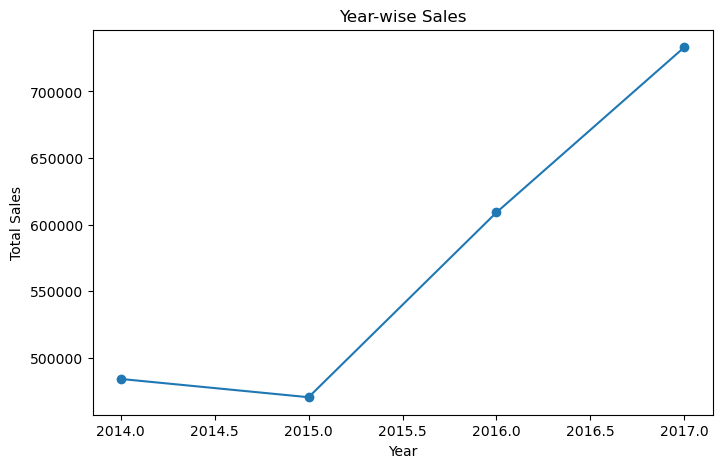

In [92]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly_summary["year"],
    yearly_summary["Total_Sales"],
    marker = "o"
)

plt.title("Year-wise Sales")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

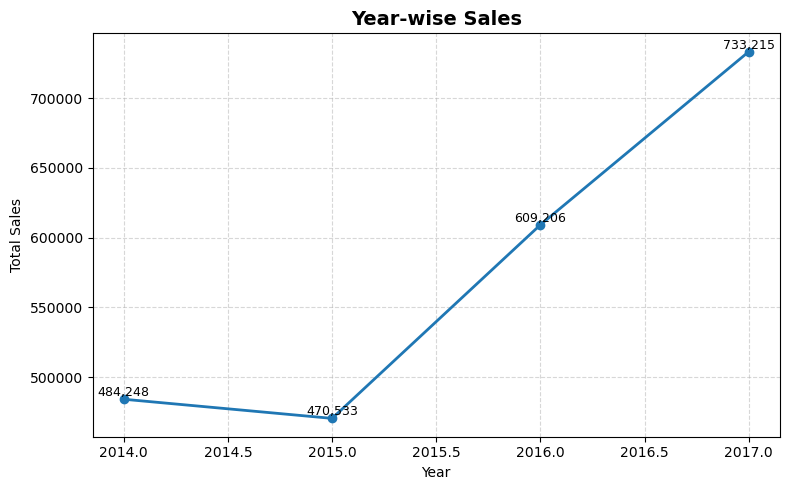

In [93]:
plt.figure(figsize=(8,5))

plt.plot(
    yearly_summary["year"],
    yearly_summary["Total_Sales"],
    marker="o",
    linewidth=2
)

plt.title("Year-wise Sales", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True, linestyle="--", alpha=0.5)

# Add data labels
for x, y in zip(yearly_summary["year"], yearly_summary["Total_Sales"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

In [58]:
region_summary = (
    df.groupby("region").agg(
        Total_Sales = ("sales", "sum"),
        Total_Profit = ("profit", "sum"),
        Total_Orders = ("order_id","nunique")
    ).round(2)
)

region_summary = region_summary.reset_index()
region_summary

,Total_Sales,Total_Profit,Total_Orders
region,,,
Central,501239.89,39706.36,1175
East,678781.24,91522.78,1401
South,391721.90,46749.43,822
West,725457.82,108418.45,1611


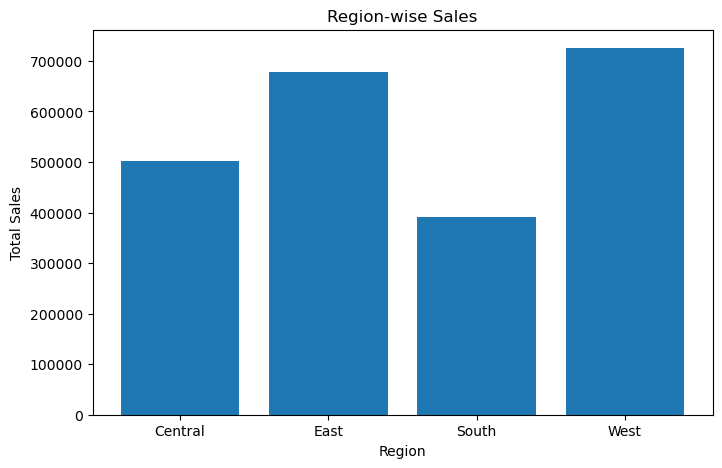

In [96]:
plt.figure(figsize=(8,5))
plt.bar(
    region_summary["region"],
    region_summary["Total_Sales"]
)

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

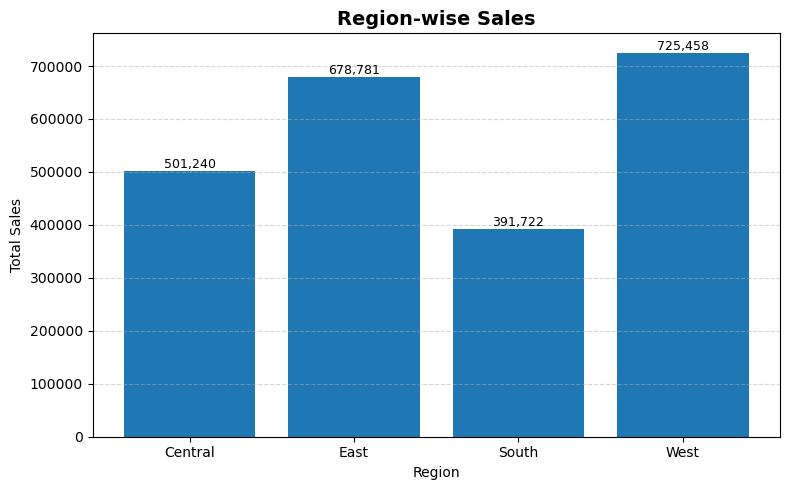

In [97]:
plt.figure(figsize=(8,5))

plt.bar(
    region_summary["region"],
    region_summary["Total_Sales"]
)

plt.title("Region-wise Sales", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales")

for x, y in zip(region_summary["region"], region_summary["Total_Sales"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [61]:
category_summary = (
    df.groupby("category").agg(
        Total_Sales = ("sales", "sum"),
        Total_Profit = ("profit","sum"),
        Total_Orders = ("order_id","nunique")
    ).round(2)
)

category_summary = category_summary.reset_index()
category_summary

,category,Total_Sales,Total_Profit,Total_Orders
0,Furniture,741999.80,18451.27,1764
1,Office Supplies,719047.03,122490.80,3742
2,Technology,836154.03,145454.95,1544


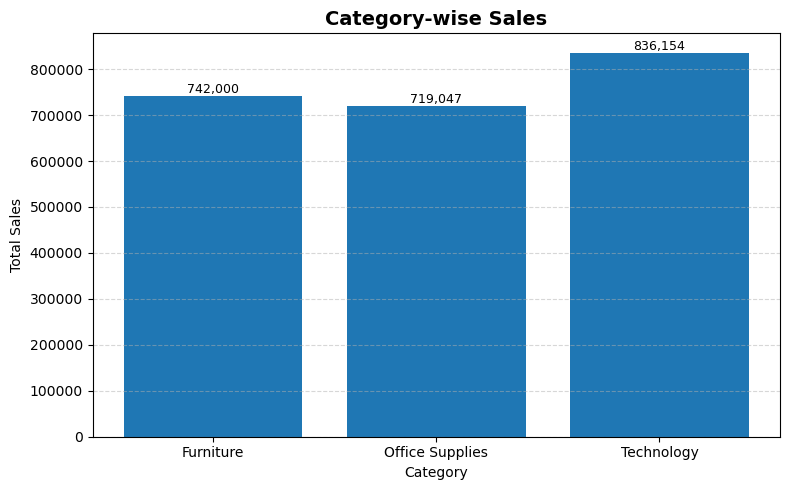

In [98]:
plt.figure(figsize=(8,5))

plt.bar(
    category_summary["category"],
    category_summary["Total_Sales"]
)

plt.title("Category-wise Sales", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales")

for x, y in zip(category_summary["category"], category_summary["Total_Sales"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [99]:
segment_summary = (
    df.groupby("segment").agg(
        Total_Sales = ("sales", "sum"),
        Total_Profit = ("profit","sum"),
        Total_Orders = ("order_id", "nunique")
    ).round(2)
)

segment_summary = segment_summary.reset_index()
segment_summary

,segment,Total_Sales,Total_Profit,Total_Orders
0,Consumer,1161401.34,134119.21,2586
1,Corporate,706146.37,91979.13,1514
2,Home Office,429653.15,60298.68,909


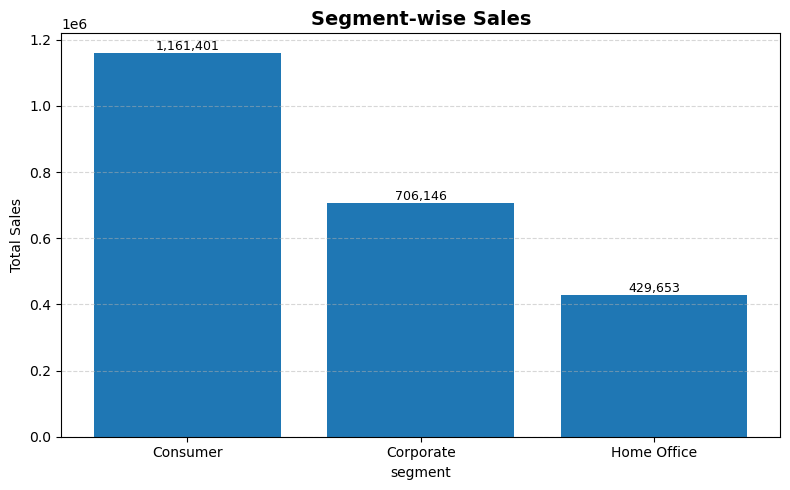

In [101]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_summary["segment"],
    segment_summary["Total_Sales"]
)

plt.title("Segment-wise Sales", fontsize=14, fontweight="bold")
plt.xlabel("segment")
plt.ylabel("Total Sales")

for x, y in zip(segment_summary["segment"], segment_summary["Total_Sales"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [102]:
shipmode_summary = (
    df.groupby("ship_mode").agg(
        Total_Sales = ("sales","sum"),
        Total_Profit = ("profit", "sum"),
        Total_Orders = ("order_id", "nunique")                     
    ).round(2)
)

shipmode_summary = shipmode_summary.reset_index()
shipmode_summary

,ship_mode,Total_Sales,Total_Profit,Total_Orders
0,First Class,351428.42,48969.84,787
1,Same Day,128363.12,15891.76,264
2,Second Class,459193.57,57446.64,964
3,Standard Class,1358215.74,164088.79,2994


In [ ]:
#plt.figure(figsize=(8,5))

plt.bar(
    shipmode_summary["ship_mode"],
    shipmode_summary["ship_mode"],["Total_Sales"]
)

plt.title("Ship_mode-wise Sales", fontsize=14, fontweight="bold")
plt.xlabel("ship_mode")
plt.ylabel("Total Sales")

for x, y in zip(shipmode_summary["ship_mode"], shipmode_summary["Total_Sales"]):
    plt.text(x, y, f"{y:,.0f}", ha="center", va="bottom", fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [86]:
state_category = (
    df.groupby("state").agg(
        Total_Sales = ("sales", "sum"),
        Total_Profit = ("profit", "sum"),
        Total_Orders = ("order_id", "nunique")
    ).round(2)
)

state_category = state_category.reset_index()
state_category.head()

,state,Total_Sales,Total_Profit,Total_Orders
0,Alabama,19510.64,5786.83,34
1,Arizona,35282.00,-3427.92,108
2,Arkansas,11678.13,4008.69,27
3,California,457687.63,76381.39,1021
4,Colorado,32108.12,-6527.86,79


In [107]:
city_category = (
    df.groupby("city").agg(
        Total_Sales = ("sales", "sum"),
        Total_Prfit = ("profit", "sum"),
        Total_Orders = ("order_id", "nunique")
    ).round(2)
)

city_category = city_category.reset_index()
city_category.head()

,city,Total_Sales,Total_Prfit,Total_Orders
0,Aberdeen,25.50,6.63,1
1,Abilene,1.39,-3.76,1
2,Akron,2729.99,-186.64,10
3,Albuquerque,2220.16,634.09,7
4,Alexandria,5519.57,318.62,6


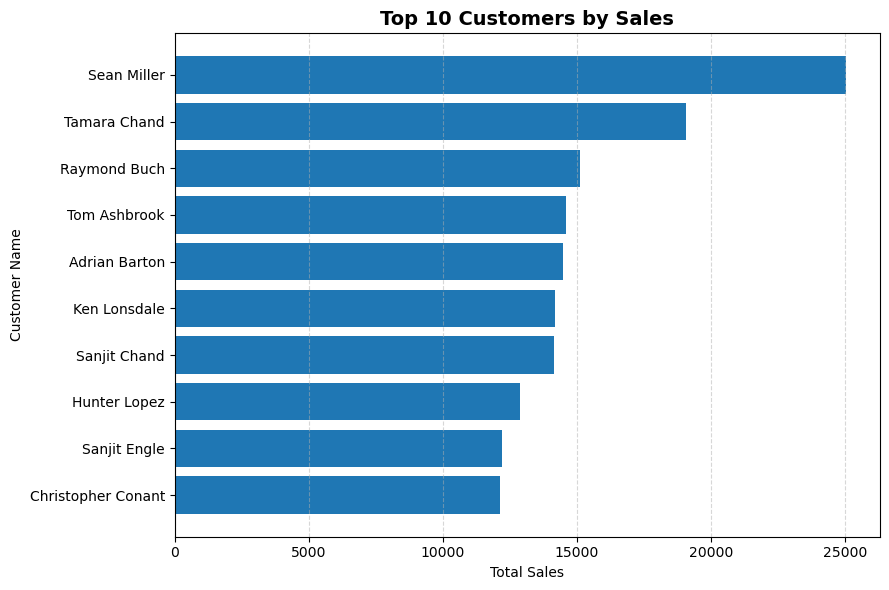

In [108]:
top_customers = (
    df.groupby("customer_name")
      .agg(Total_Sales=("sales", "sum"))
      .sort_values("Total_Sales", ascending=False)
      .head(10)
      .reset_index()
      .sort_values("Total_Sales")
)

plt.figure(figsize=(9,6))

plt.barh(
    top_customers["customer_name"],
    top_customers["Total_Sales"]
)

plt.title("Top 10 Customers by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

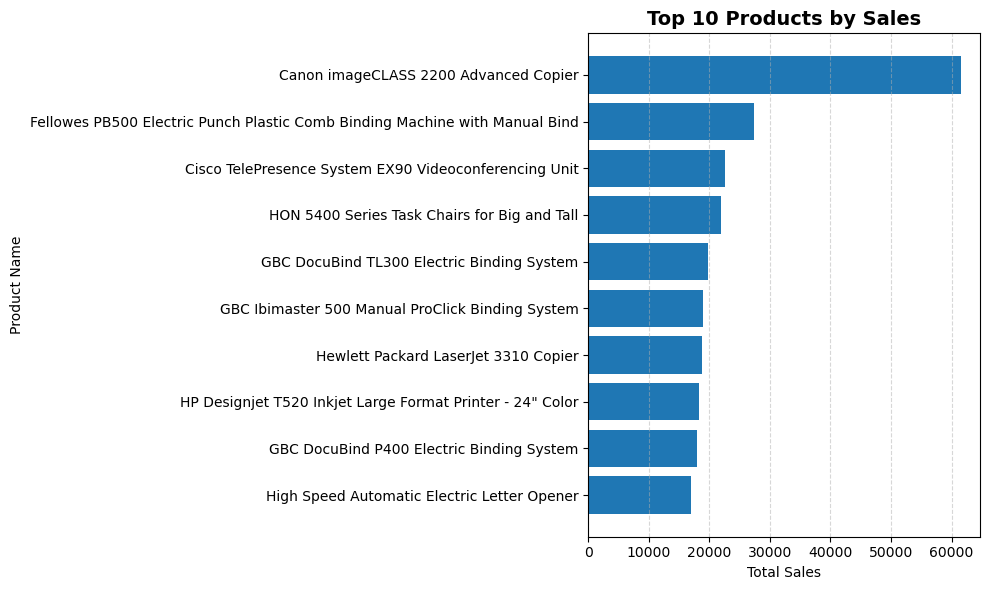

In [109]:
top_products = (
    df.groupby("product_name")
      .agg(Total_Sales=("sales", "sum"))
      .sort_values("Total_Sales", ascending=False)
      .head(10)
      .reset_index()
      .sort_values("Total_Sales")
)

plt.figure(figsize=(10,6))

plt.barh(
    top_products["product_name"],
    top_products["Total_Sales"]
)

plt.title("Top 10 Products by Sales", fontsize=14, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

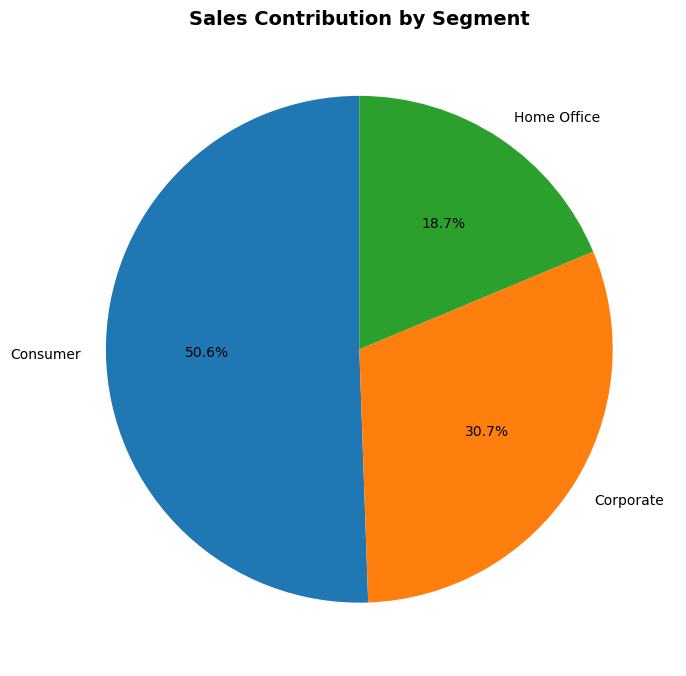

In [110]:
segment_sales = (
    df.groupby("segment")["sales"]
      .sum()
)

plt.figure(figsize=(7,7))

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Contribution by Segment", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

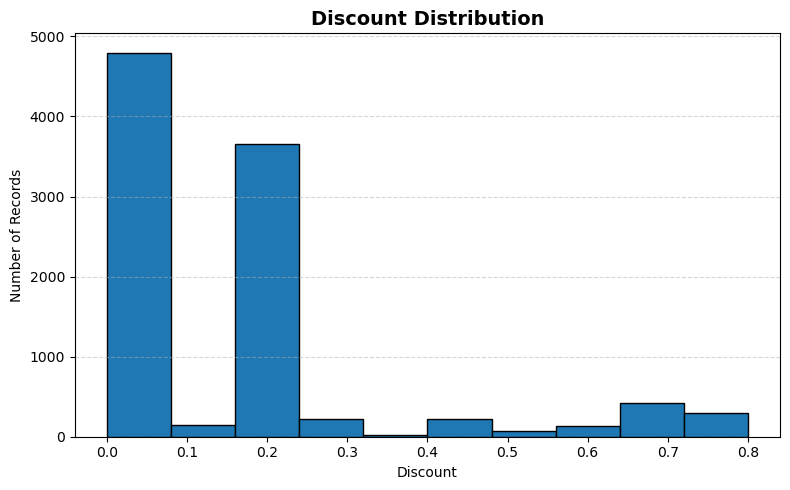

In [111]:
plt.figure(figsize=(8,5))

plt.hist(
    df["discount"],
    bins=10,
    edgecolor="black"
)

plt.title("Discount Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Number of Records")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

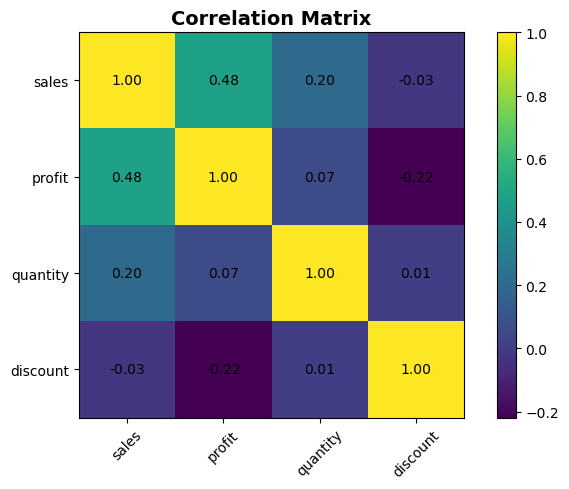

In [112]:
import numpy as np

numeric_columns = df[
    ["sales", "profit", "quantity", "discount"]
]

correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(7,5))

plt.imshow(
    correlation_matrix,
    interpolation="nearest"
)

plt.title("Correlation Matrix", fontsize=14, fontweight="bold")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        plt.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

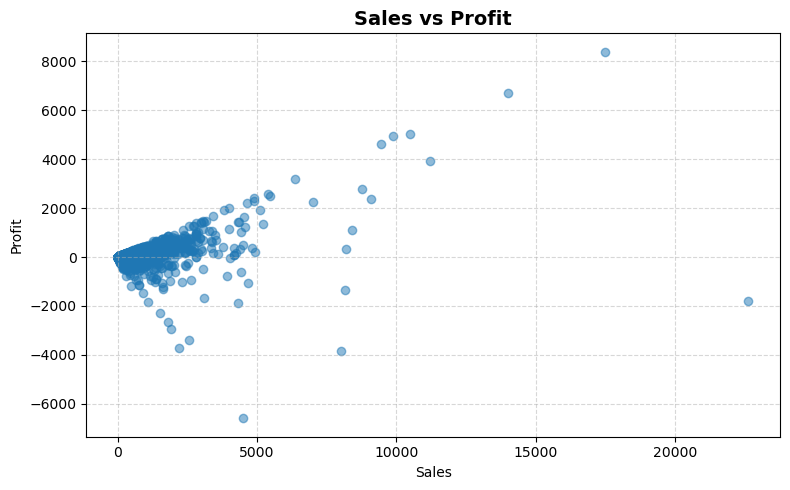

In [113]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["sales"],
    df["profit"],
    alpha=0.5
)

plt.title("Sales vs Profit", fontsize=14, fontweight="bold")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

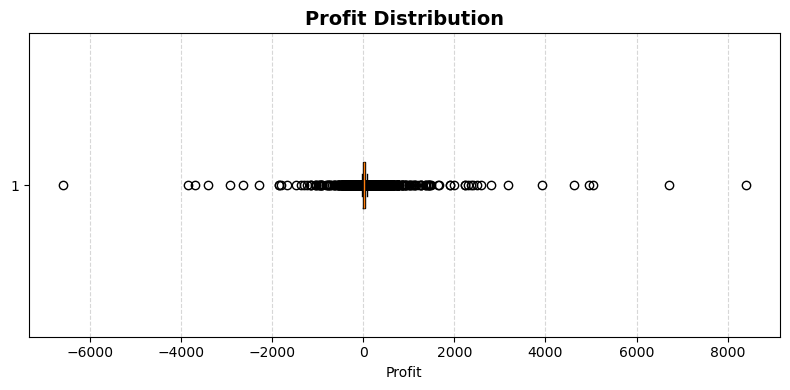

In [114]:
plt.figure(figsize=(8,4))

plt.boxplot(
    df["profit"],
    vert=False
)

plt.title("Profit Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Profit")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()